In [ ]:
!pip install sentence-transformers seaborn matplotlib

from sentence_transformers import SentenceTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team won the match by six wickets",
    "The captain set an aggressive field",

    # Cooking (3)
    "I added spices to enhance the flavor of the curry",
    "The cake was baked at 180 degrees",
    "She chopped vegetables for the salad",

    # Cybersecurity (3)
    "Strong passwords help prevent hacking",
    "The system detected a malware attack",
    "Encryption protects sensitive data"
]

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

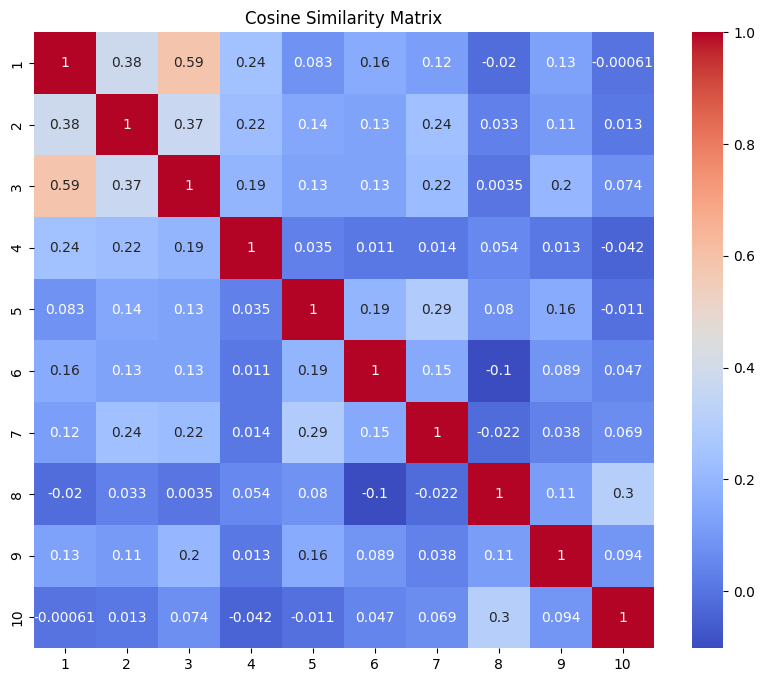

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm',
            xticklabels=range(1,11),
            yticklabels=range(1,11))
plt.title("Cosine Similarity Matrix")
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 similar sentences
top_indices = similarities.argsort()[-2:][::-1]

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}")
    print()

Sentence: The team won the match by six wickets
Similarity Score: 0.7324

Sentence: The batsman scored a century in the match
Similarity Score: 0.5682

